# ⚙️ Chemical Engineering: Process Control & Simulation
**Topics Covered:** PID Control | Step Response | Transfer Functions | Feedback Loops | Stability Analysis

---

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp, odeint
from scipy.signal import step, bode, TransferFunction
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({
    'figure.facecolor': '#0f1117', 'axes.facecolor': '#1a1d27',
    'axes.edgecolor': '#444', 'axes.labelcolor': '#cdd6f4',
    'xtick.color': '#cdd6f4', 'ytick.color': '#cdd6f4',
    'text.color': '#cdd6f4', 'grid.color': '#2a2d3e',
    'grid.linestyle': '--', 'font.family': 'monospace',
})
COLORS = ['#89b4fa', '#a6e3a1', '#fab387', '#f38ba8', '#cba6f7', '#94e2d5']
print('✅ Libraries loaded.')

✅ Libraries loaded.


---
## 1 · First & Second Order Process Step Response

**First-order:** $G(s) = \dfrac{K}{\tau s + 1}$ &nbsp;&nbsp; **Second-order:** $G(s) = \dfrac{K\omega_n^2}{s^2 + 2\zeta\omega_n s + \omega_n^2}$

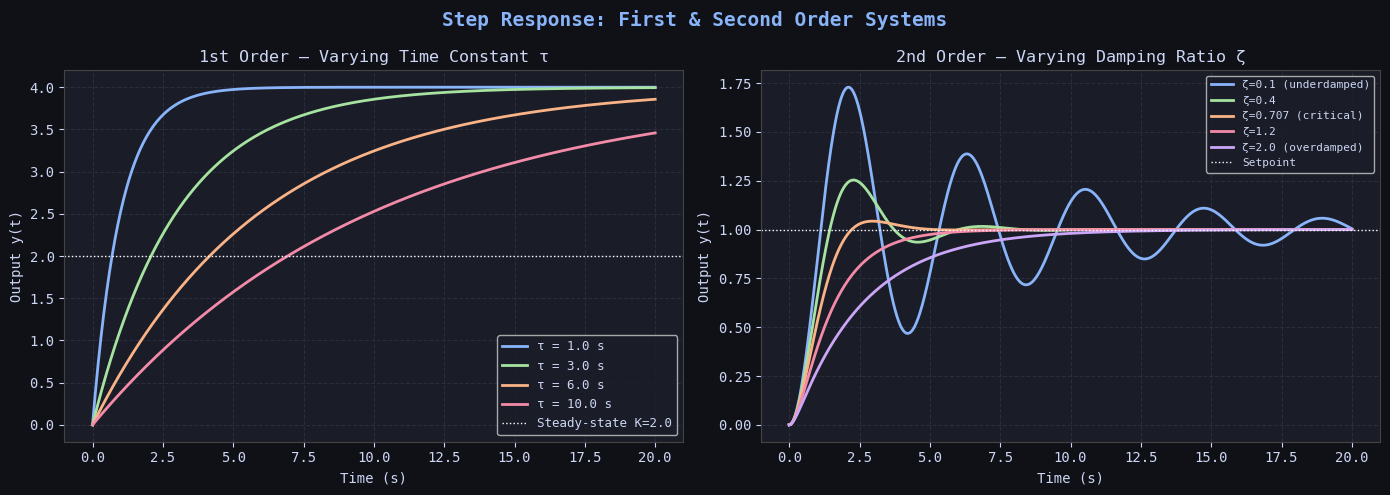

In [2]:
t = np.linspace(0, 20, 1000)

# --- First-order responses for different time constants ---
K = 2.0
taus = [1.0, 3.0, 6.0, 10.0]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Step Response: First & Second Order Systems', fontsize=14, fontweight='bold', color='#89b4fa')

for i, tau in enumerate(taus):
    sys = TransferFunction([K], [tau, 1])
    t_out, y_out = step(sys, T=t)
    axes[0].plot(t_out, K * y_out, color=COLORS[i], lw=2, label=f'τ = {tau} s')

axes[0].axhline(K, color='white', lw=1, linestyle=':', label=f'Steady-state K={K}')
axes[0].set(xlabel='Time (s)', ylabel='Output y(t)', title='1st Order — Varying Time Constant τ')
axes[0].legend(fontsize=9); axes[0].grid(True)

# --- Second-order responses for different damping ratios ---
wn   = 1.5   # natural frequency rad/s
zetas = [0.1, 0.4, 0.707, 1.2, 2.0]
labels_z = ['ζ=0.1 (underdamped)', 'ζ=0.4', 'ζ=0.707 (critical)', 'ζ=1.2', 'ζ=2.0 (overdamped)']

for i, (zeta, lbl) in enumerate(zip(zetas, labels_z)):
    sys2 = TransferFunction([wn**2], [1, 2*zeta*wn, wn**2])
    t_out, y_out = step(sys2, T=t)
    axes[1].plot(t_out, y_out, color=COLORS[i % len(COLORS)], lw=2, label=lbl)

axes[1].axhline(1.0, color='white', lw=1, linestyle=':', label='Setpoint')
axes[1].set(xlabel='Time (s)', ylabel='Output y(t)', title='2nd Order — Varying Damping Ratio ζ')
axes[1].legend(fontsize=8); axes[1].grid(True)

plt.tight_layout()
plt.savefig('step_response.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 2 · PID Controller — Closed-Loop Simulation

$$u(t) = K_p e(t) + K_i \int_0^t e(\tau)d\tau + K_d \frac{de}{dt}$$

Process model: first-order + dead time (FOPDT): $G(s) = \dfrac{K e^{-\theta s}}{\tau s + 1}$

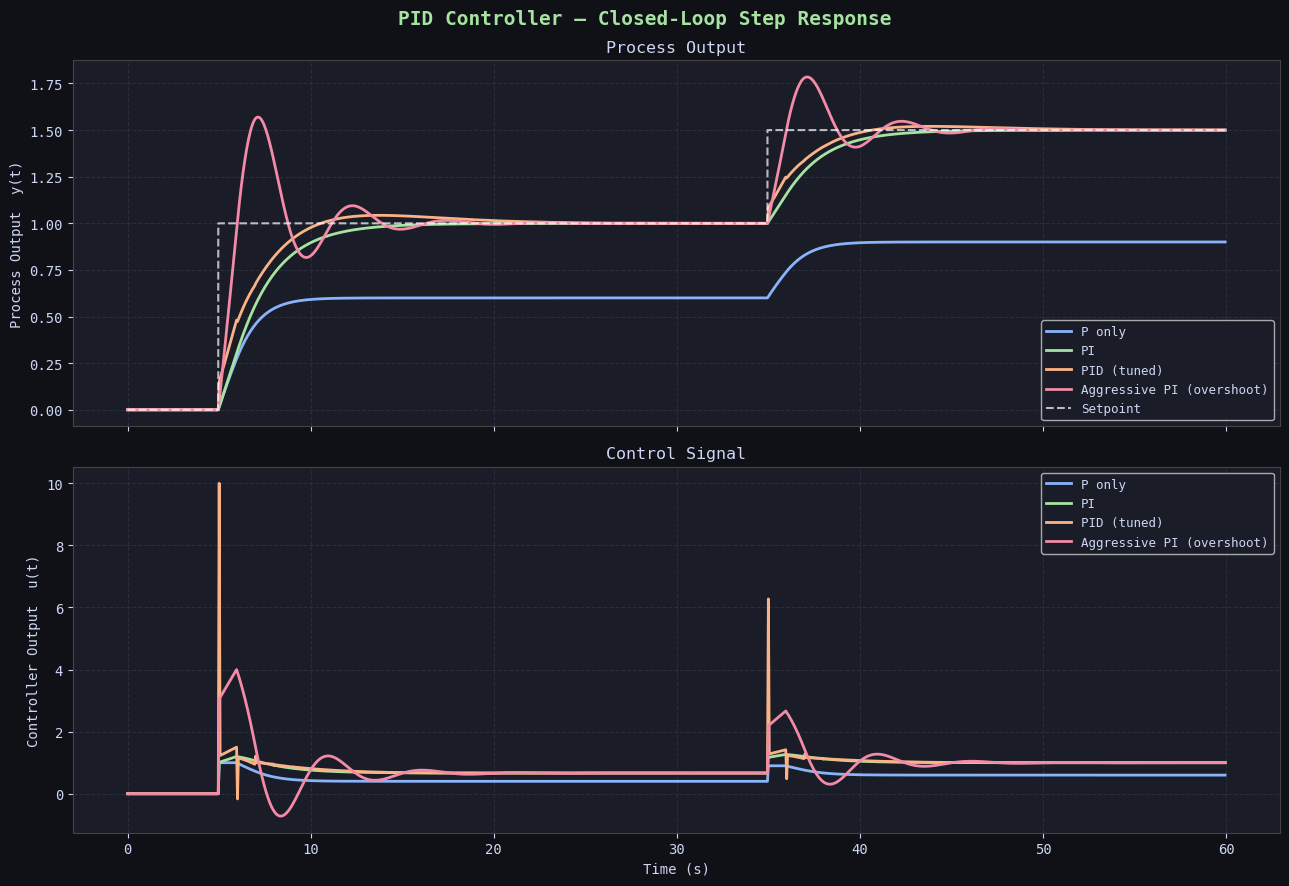


Tuned PID Performance Metrics:
  IAE (Integral Absolute Error) = 4.287
  ISE (Integral Square Error)   = 2.188


In [3]:
def simulate_pid(Kp, Ki, Kd, setpoint=1.0, K_proc=1.5, tau_proc=5.0, theta=1.0,
                 t_end=60, dt=0.05):
    """Simulate PID on a FOPDT process using discrete approximation."""
    t      = np.arange(0, t_end, dt)
    N      = len(t)
    delay_steps = max(1, int(theta / dt))

    y      = np.zeros(N)   # process output
    u      = np.zeros(N)   # controller output
    e      = np.zeros(N)   # error
    e_int  = 0.0           # integral term
    e_prev = 0.0

    sp = np.where(t >= 5, setpoint, 0.0)     # step at t=5 s
    sp = np.where(t >= 35, 1.5, sp)           # second step at t=35 s

    for k in range(1, N):
        # Dead-time: use delayed output
        k_delayed = max(0, k - delay_steps)
        y_delayed = y[k_delayed]

        e[k]   = sp[k] - y_delayed
        e_int += e[k] * dt
        de_dt  = (e[k] - e_prev) / dt

        u[k]   = np.clip(Kp*e[k] + Ki*e_int + Kd*de_dt, -10, 10)

        # First-order process dynamics
        dydt   = (-y[k-1] + K_proc * u[k]) / tau_proc
        y[k]   = y[k-1] + dydt * dt
        e_prev = e[k]

    return t, y, u, sp, e

# Compare P, PI, PID tuning
controllers = [
    {'Kp': 1.0, 'Ki': 0.0,  'Kd': 0.0,  'label': 'P only'},
    {'Kp': 1.0, 'Ki': 0.2,  'Kd': 0.0,  'label': 'PI'},
    {'Kp': 1.2, 'Ki': 0.3,  'Kd': 0.5,  'label': 'PID (tuned)'},
    {'Kp': 3.0, 'Ki': 1.0,  'Kd': 0.0,  'label': 'Aggressive PI (overshoot)'},
]

fig, axes = plt.subplots(2, 1, figsize=(13, 9), sharex=True)
fig.suptitle('PID Controller — Closed-Loop Step Response', fontsize=14, fontweight='bold', color='#a6e3a1')

for i, ctrl in enumerate(controllers):
    t, y, u, sp, e = simulate_pid(**{k:v for k,v in ctrl.items() if k != 'label'})
    axes[0].plot(t, y,  color=COLORS[i], lw=2, label=ctrl['label'])
    axes[1].plot(t, u,  color=COLORS[i], lw=2, label=ctrl['label'])

axes[0].step(t, sp, color='white', lw=1.5, linestyle='--', alpha=0.7, label='Setpoint')
axes[0].set(ylabel='Process Output  y(t)', title='Process Output')
axes[0].legend(fontsize=9); axes[0].grid(True)

axes[1].set(xlabel='Time (s)', ylabel='Controller Output  u(t)', title='Control Signal')
axes[1].legend(fontsize=9); axes[1].grid(True)

plt.tight_layout()
plt.savefig('pid_control.png', dpi=150, bbox_inches='tight')
plt.show()

# Performance metrics for tuned PID
t, y, u, sp, e = simulate_pid(Kp=1.2, Ki=0.3, Kd=0.5)
iae = np.trapz(np.abs(e), t)
ise = np.trapz(e**2, t)
print(f'\nTuned PID Performance Metrics:')
print(f'  IAE (Integral Absolute Error) = {iae:.3f}')
print(f'  ISE (Integral Square Error)   = {ise:.3f}')

---
## 3 · Bode Plot — Frequency Response Analysis

Used to assess **gain margin** and **phase margin** — key stability indicators.

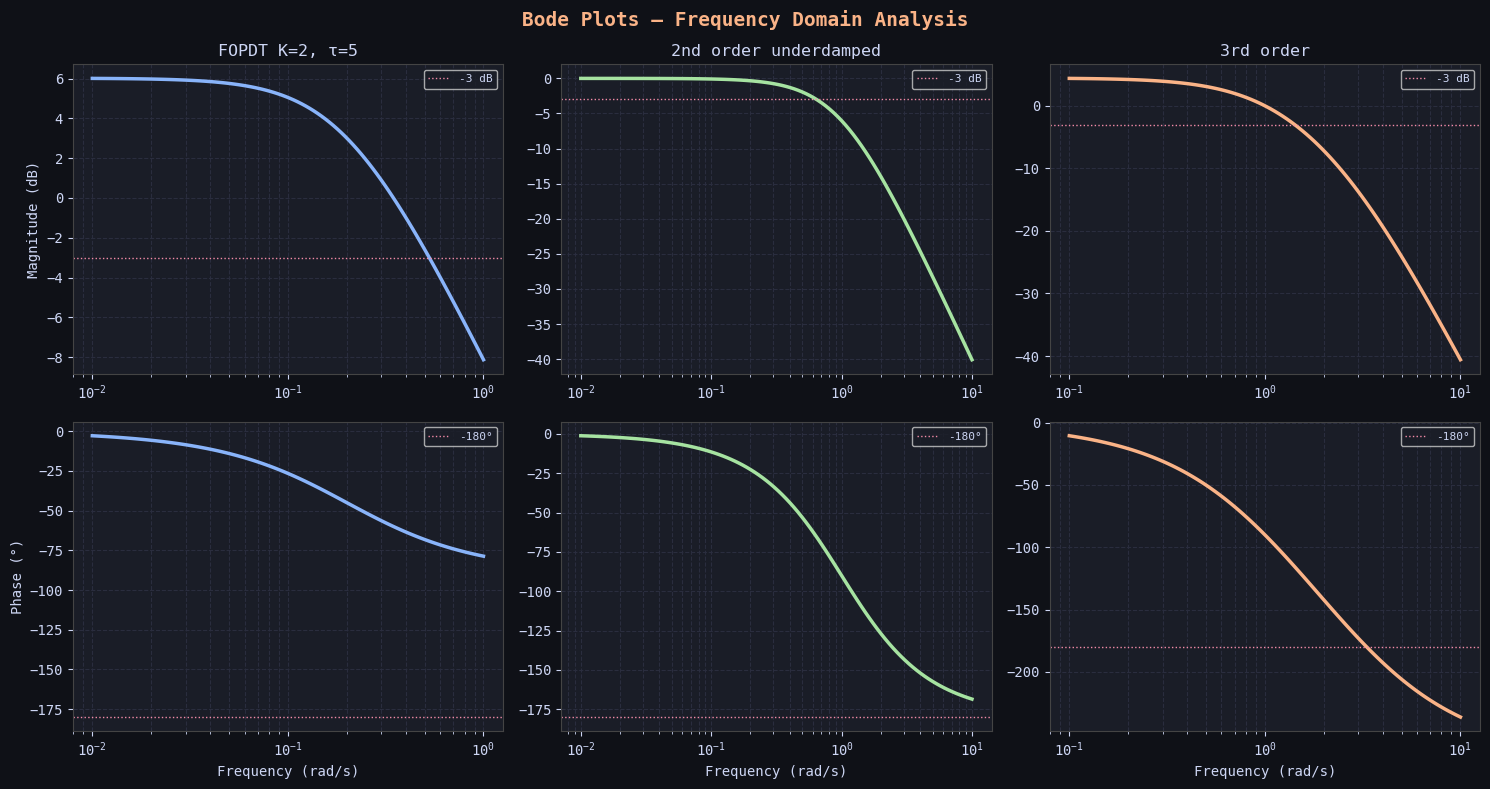

In [5]:
systems = [
    (TransferFunction([2],        [5, 1]),             'FOPDT K=2, τ=5'),
    (TransferFunction([1],        [1, 2, 1]),           '2nd order underdamped'),
    (TransferFunction([10],       [1, 6, 11, 6]),       '3rd order'),
]

fig, axes = plt.subplots(2, len(systems), figsize=(15, 8))
fig.suptitle('Bode Plots — Frequency Domain Analysis', fontsize=14, fontweight='bold', color='#fab387')

for col, (sys, lbl) in enumerate(systems):
    w, mag, phase = bode(sys)
    axes[0, col].semilogx(w, mag,   color=COLORS[col], lw=2.5)
    axes[0, col].axhline(-3, color='#f38ba8', lw=1, linestyle=':', label='-3 dB')
    axes[0, col].set(ylabel='Magnitude (dB)' if col==0 else '', title=lbl)
    axes[0, col].legend(fontsize=8); axes[0, col].grid(True, which='both')

    axes[1, col].semilogx(w, phase, color=COLORS[col], lw=2.5)
    axes[1, col].axhline(-180, color='#f38ba8', lw=1, linestyle=':', label='-180°')
    axes[1, col].set(xlabel='Frequency (rad/s)', ylabel='Phase (°)' if col==0 else '')
    axes[1, col].legend(fontsize=8); axes[1, col].grid(True, which='both')

plt.tight_layout()
plt.savefig('bode_plots.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 4 · CSTR Temperature Control — Nonlinear ODE Simulation

Coupled energy and mass balance with PI feedback on jacket temperature:

$$\frac{dC_A}{dt} = \frac{F}{V}(C_{A0}-C_A) - k(T)C_A \qquad \frac{dT}{dt} = \frac{F}{V}(T_0-T) + \frac{-\Delta H_{rx}}{\rho C_p}k(T)C_A + \frac{UA}{\rho C_p V}(T_c - T)$$

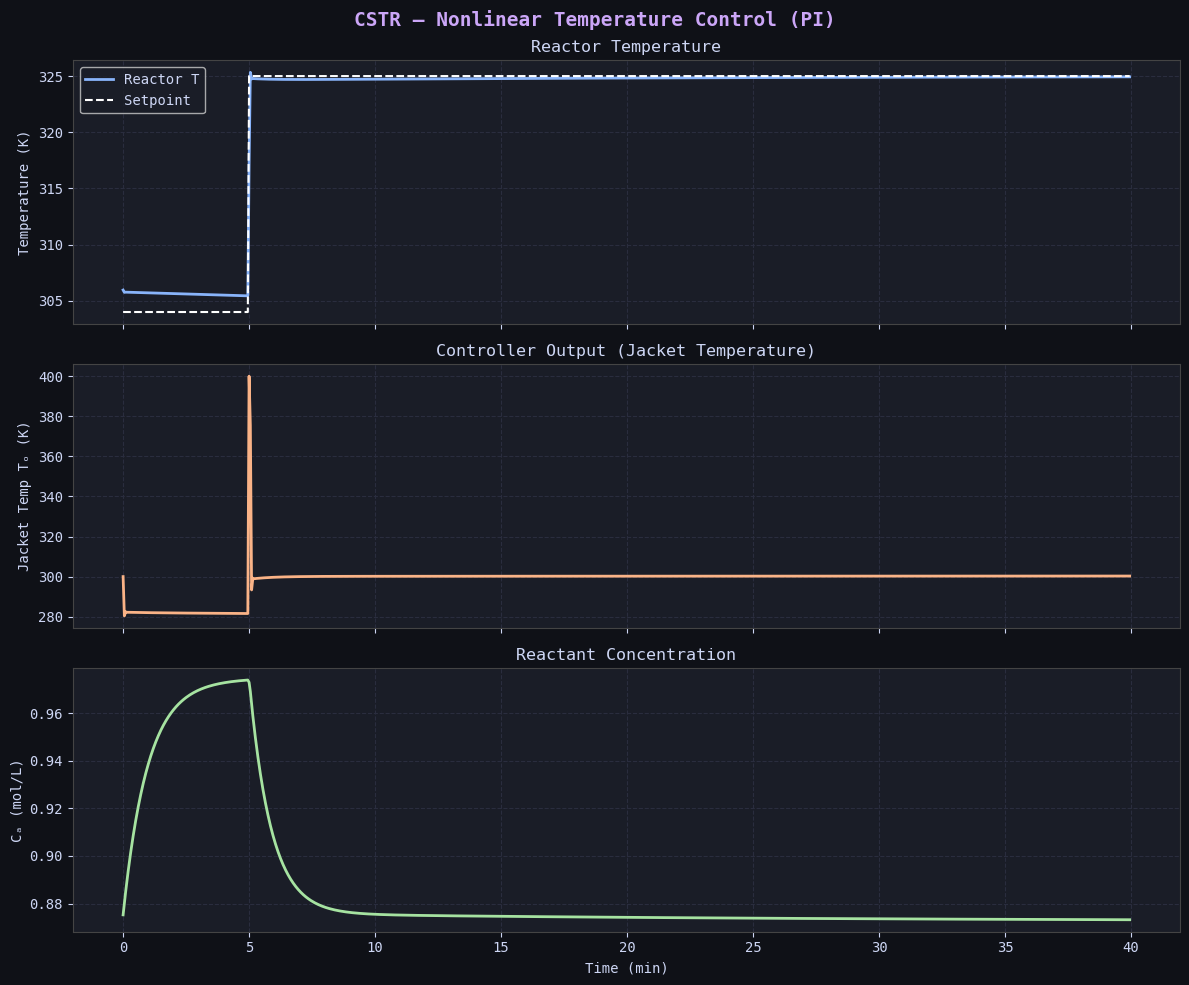

In [6]:
# Process parameters
p = dict(
    F=100.0, V=100.0, CA0=1.0, T0=350.0,
    Ea=72750.0, A_pre=7.2e10, R=8.314,
    dH=-5e4, rho=1000.0, Cp=0.239, UA=5e4,
    T_setpoint=325.0,
    Kp_ctrl=10.0, Ki_ctrl=0.5,
    Tc_min=250.0, Tc_max=400.0,
)

def cstr_odes(t, y, p, Tc):
    CA, T = y
    k = p['A_pre'] * np.exp(-p['Ea'] / (p['R'] * T))
    rA = k * CA
    dCAdt = (p['F']/p['V'])*(p['CA0'] - CA) - rA
    dTdt  = (p['F']/p['V'])*(p['T0'] - T) \
            + (-p['dH'])/(p['rho']*p['Cp']) * rA \
            + p['UA']/(p['rho']*p['Cp']*p['V']) * (Tc - T)
    return [dCAdt, dTdt]

# Simulate with PI controller
dt = 0.05; t_end = 40
t_arr = np.arange(0, t_end, dt)
CA_arr, T_arr, Tc_arr = [], [], []

y_curr = [0.87, 304.0]   # initial steady-state guess
e_int  = 0.0

for t_k in t_arr:
    T_sp = p['T_setpoint'] if t_k >= 5 else 304.0
    e    = T_sp - y_curr[1]
    e_int += e * dt
    Tc   = np.clip(300.0 + p['Kp_ctrl']*e + p['Ki_ctrl']*e_int,
                   p['Tc_min'], p['Tc_max'])

    sol = solve_ivp(cstr_odes, [0, dt], y_curr, args=(p, Tc), method='RK45',
                    rtol=1e-8, dense_output=False)
    y_curr = sol.y[:, -1].tolist()

    CA_arr.append(y_curr[0])
    T_arr.append(y_curr[1])
    Tc_arr.append(Tc)

fig, axes = plt.subplots(3, 1, figsize=(12, 10), sharex=True)
fig.suptitle('CSTR — Nonlinear Temperature Control (PI)', fontsize=14, fontweight='bold', color='#cba6f7')

sp_arr = np.where(t_arr >= 5, p['T_setpoint'], 304.0)

axes[0].plot(t_arr, T_arr,  color=COLORS[0], lw=2, label='Reactor T')
axes[0].plot(t_arr, sp_arr, color='white', lw=1.5, linestyle='--', label='Setpoint')
axes[0].set(ylabel='Temperature (K)', title='Reactor Temperature')
axes[0].legend(); axes[0].grid(True)

axes[1].plot(t_arr, Tc_arr, color=COLORS[2], lw=2)
axes[1].set(ylabel='Jacket Temp Tₒ (K)', title='Controller Output (Jacket Temperature)')
axes[1].grid(True)

axes[2].plot(t_arr, CA_arr, color=COLORS[1], lw=2)
axes[2].set(xlabel='Time (min)', ylabel='Cₐ (mol/L)', title='Reactant Concentration')
axes[2].grid(True)

plt.tight_layout()
plt.savefig('cstr_control.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 5 · Ziegler–Nichols PID Tuning — Auto-Tune Comparison

Classic Z-N rules from ultimate gain $K_u$ and period $P_u$:

| Controller | $K_p$ | $T_i$ | $T_d$ |
|------------|--------|--------|--------|
| P | $0.5K_u$ | — | — |
| PI | $0.45K_u$ | $0.83P_u$ | — |
| PID | $0.6K_u$ | $0.5P_u$ | $0.125P_u$ |

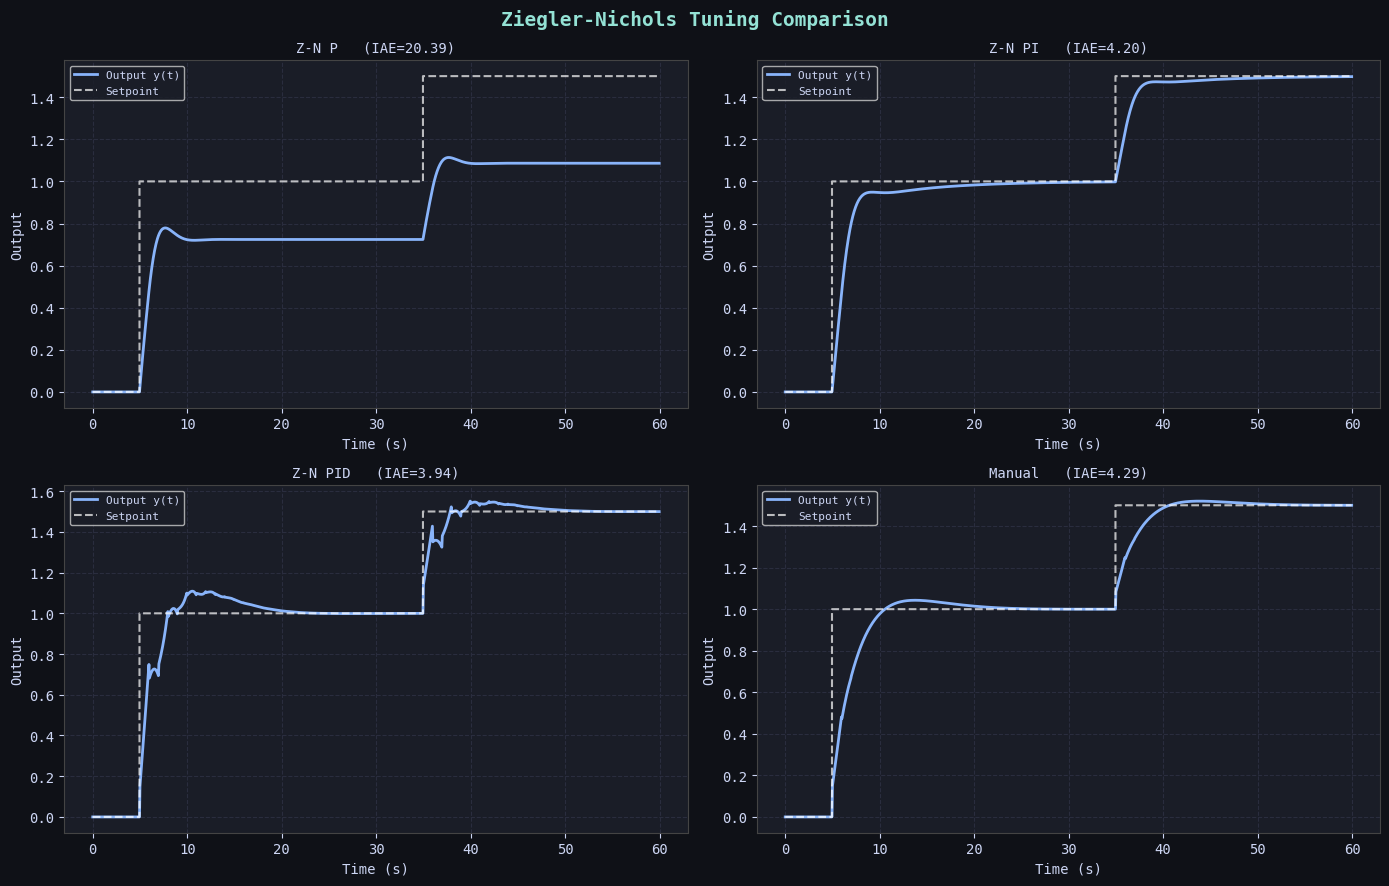

In [7]:
# Z-N parameters (typically found via relay feedback or open-loop test)
Ku = 3.5   # ultimate gain
Pu = 8.0   # ultimate period (s)

zn_tunings = {
    'Z-N P':   {'Kp': 0.50*Ku,  'Ki': 0,               'Kd': 0},
    'Z-N PI':  {'Kp': 0.45*Ku,  'Ki': 0.45*Ku/(0.83*Pu), 'Kd': 0},
    'Z-N PID': {'Kp': 0.60*Ku,  'Ki': 0.60*Ku/(0.50*Pu), 'Kd': 0.60*Ku*0.125*Pu},
    'Manual':  {'Kp': 1.2,       'Ki': 0.30,             'Kd': 0.5},
}

fig, axes = plt.subplots(2, 2, figsize=(14, 9))
fig.suptitle('Ziegler-Nichols Tuning Comparison', fontsize=14, fontweight='bold', color='#94e2d5')
axes = axes.flatten()

for ax, (name, params) in zip(axes, zn_tunings.items()):
    t, y, u, sp, e = simulate_pid(**params)
    ax.plot(t, y,  color=COLORS[0], lw=2, label='Output y(t)')
    ax.step(t, sp, color='white', lw=1.5, linestyle='--', alpha=0.7, label='Setpoint')
    iae = np.trapz(np.abs(e), t)
    ax.set_title(f'{name}   (IAE={iae:.2f})', fontsize=10)
    ax.set(xlabel='Time (s)', ylabel='Output')
    ax.legend(fontsize=8); ax.grid(True)

plt.tight_layout()
plt.savefig('zn_tuning.png', dpi=150, bbox_inches='tight')
plt.show()

---
## ✅ Summary

| Section | Concept | Method |
|---------|---------|--------|
| Step Response | 1st & 2nd order dynamics | `scipy.signal.TransferFunction` |
| PID Simulation | Closed-loop feedback | Discrete Euler integration |
| Bode Plot | Frequency domain, gain/phase margin | `scipy.signal.bode` |
| CSTR Control | Nonlinear ODE + PI controller | `scipy.integrate.solve_ivp` |
| Z-N Tuning | Auto-tune rules, IAE comparison | Parametric study |

> **Next steps:** Add cascade control, feedforward compensation, or MPC (Model Predictive Control).